# RQ5: Has the Cost of Living Risen Faster Than Quality of Life Since COVID?

**Research question:** Has the cost of living risen faster than quality of life since COVID, leaving people worse off in real terms?

**Hypothesis:** Cost of living rose faster than quality during and after COVID, eroding affordability for residents, particularly in cities that already had high costs. Eastern European and South Asian cities will be more resilient than Western and Latin American ones.

**Note on the data:** This analysis uses country-level Cost of Living data joined to city-level quality scores. All cross-year comparisons use the affordability ratio (local purchasing power divided by cost of living) rather than the value index. This is because the Numbeo Cost of Living scale shifts from year to year as new countries are added, which makes raw cross-year value comparisons unreliable. The affordability ratio avoids this problem because the same reference point appears in both the numerator and denominator, so it cancels out. The analysis covers 2016 to 2024. See the methodology section for why 2025 data is excluded.

## Methodology

### What we are measuring

This notebook tracks two things over time: how the quality of life in cities changed around COVID, and whether residents could actually afford to live there.

**Quality score** is a simple average of four dimensions, each scored from 0 to 100:
- Safety (how safe residents perceive their city)
- Healthcare (quality and accessibility of healthcare)
- Clean Air (100 minus the pollution index, so lower pollution = higher score)
- Low Traffic (the Numbeo Traffic Index rescaled to 0-100, so less congestion = higher score)

The quality score uses an absolute 0-100 scale for all four dimensions, which means it can be compared across years without any adjustment.

**A note on the traffic dimension:** The Numbeo Traffic Index does not run from 0 to 100. Its values range from 36 to 367, with most cities scoring above 100. Using 100 minus the raw traffic value would produce negative scores for most cities, which is meaningless. We therefore rescale the traffic index to a 0-100 range using the minimum and maximum values observed across the entire dataset (all cities, all years). This ensures the traffic dimension is comparable both across cities and across years.

### Why we use the affordability ratio, not the value index

The value index divides the quality score by the Cost of Living Index. This would be the most direct answer to the research question, but there is a problem: the Numbeo Cost of Living Index shifts its reference point each year as the sample of countries grows. Between 2019 and 2024, Numbeo added many low-cost countries to the dataset. This pushed down the global average Cost of Living Index, making every existing city look cheaper on paper even if nothing actually changed in that city. Any improvement in the value index over time is therefore partly a measurement artefact rather than a real change.

The affordability ratio solves this problem. It is calculated as:

**Affordability ratio = Local Purchasing Power Index / Cost of Living Index**

Both the purchasing power and cost of living figures are expressed relative to the same reference point each year. When you divide them, that reference point cancels out, leaving a measure that reflects the genuine relationship between what residents earn and what they pay. A ratio above 1 means residents can afford more than the baseline; a rising ratio over time means real affordability is improving.

### Why the analysis ends at 2024

We initially ran the analysis through to 2025, but the 2025 Numbeo purchasing power data contains changes that have no economic basis. India shows a 35% increase in purchasing power in a single year; Brazil shows 41%; Germany 26%; Russia 36%. These countries have no shared economic event that could explain simultaneous large increases. The most likely explanation is a data quality issue in the 2025 Numbeo dataset. Including 2025 would artificially inflate the affordability recovery finding. The analysis therefore ends at 2024. The full COVID shock (2020-2021) and the recovery period (2022-2024) are captured within the 2016-2024 window.

### Consistent city panel

To make fair comparisons over time, the analysis only includes cities that appear in all 9 years of data (2016-2024) across all four quality sub-index files, and whose country also has cost of living data in all 9 years. This gives a consistent panel of 125 cities. Cities that dropped in or out of the Numbeo dataset over time are excluded to avoid the composition of the sample changing the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

PRE_COVID      = 2019
COVID_YEAR     = 2020
RECOVERY_START = 2022
POST_COVID     = 2024   # 2025 excluded: Numbeo 2025 purchasing power data contains
                        # implausible single-year spikes (e.g. India +35%, Brazil +41%)
                        # inconsistent with any macroeconomic source. 2024 is the last
                        # year with internally consistent PP values across the dataset.
YEARS          = list(range(2016, 2025))   # load 2016-2024 only

PALETTE = {
    'quality': '#0D9488', 'value': '#7C3AED', 'affordability': '#F59E0B',
    'covid': '#EF4444', 'recovery': '#6366F1', 'baseline': '#94A3B8',
    'gained': '#10B981', 'lost': '#EF4444',
}

REGION_COLORS = {
    'Eastern Europe': '#3B82F6', 'Western Europe': '#6366F1',
    'North America': '#F59E0B', 'Latin America': '#10B981',
    'East Asia': '#EF4444', 'Southeast Asia': '#EC4899',
    'South Asia': '#8B5CF6', 'MENA': '#F97316',
    'Sub-Saharan Africa': '#6B7280', 'Oceania': '#14B8A6', 'Other': '#94A3B8',
}

REGION_MAP = {
    'Romania': 'Eastern Europe', 'Bulgaria': 'Eastern Europe', 'Hungary': 'Eastern Europe',
    'Czech Republic': 'Eastern Europe', 'Poland': 'Eastern Europe', 'Serbia': 'Eastern Europe',
    'Croatia': 'Eastern Europe', 'Slovakia': 'Eastern Europe', 'Slovenia': 'Eastern Europe',
    'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Russia': 'Eastern Europe',
    'Bosnia And Herzegovina': 'Eastern Europe', 'North Macedonia': 'Eastern Europe',
    'Albania': 'Eastern Europe', 'Moldova': 'Eastern Europe', 'Estonia': 'Eastern Europe',
    'Latvia': 'Eastern Europe', 'Lithuania': 'Eastern Europe', 'Montenegro': 'Eastern Europe',
    'Georgia': 'Eastern Europe', 'Armenia': 'Eastern Europe', 'Azerbaijan': 'Eastern Europe',
    'Kazakhstan': 'Eastern Europe', 'Kosovo (Disputed Territory)': 'Eastern Europe',
    'Germany': 'Western Europe', 'France': 'Western Europe', 'Spain': 'Western Europe',
    'Italy': 'Western Europe', 'Portugal': 'Western Europe', 'Netherlands': 'Western Europe',
    'Belgium': 'Western Europe', 'Switzerland': 'Western Europe', 'Austria': 'Western Europe',
    'Sweden': 'Western Europe', 'Norway': 'Western Europe', 'Denmark': 'Western Europe',
    'Finland': 'Western Europe', 'Ireland': 'Western Europe', 'Luxembourg': 'Western Europe',
    'Greece': 'Western Europe', 'Cyprus': 'Western Europe', 'Malta': 'Western Europe',
    'Iceland': 'Western Europe', 'United Kingdom': 'Western Europe',
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'Chile': 'Latin America', 'Peru': 'Latin America', 'Ecuador': 'Latin America',
    'Bolivia': 'Latin America', 'Uruguay': 'Latin America', 'Paraguay': 'Latin America',
    'Costa Rica': 'Latin America', 'Guatemala': 'Latin America',
    'Dominican Republic': 'Latin America', 'Venezuela': 'Latin America',
    'Honduras': 'Latin America', 'El Salvador': 'Latin America', 'Panama': 'Latin America',
    'Jamaica': 'Latin America', 'Trinidad And Tobago': 'Latin America',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',
    'Thailand': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Malaysia': 'Southeast Asia', 'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia',
    'Cambodia': 'Southeast Asia',
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',
    'Israel': 'MENA', 'Turkey': 'MENA', 'Iran': 'MENA', 'Iraq': 'MENA',
    'Jordan': 'MENA', 'Lebanon': 'MENA', 'Saudi Arabia': 'MENA',
    'United Arab Emirates': 'MENA', 'Qatar': 'MENA', 'Kuwait': 'MENA',
    'Bahrain': 'MENA', 'Oman': 'MENA', 'Morocco': 'MENA', 'Egypt': 'MENA',
    'Algeria': 'MENA', 'Tunisia': 'MENA', 'Libya': 'MENA',
    'South Africa': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa',
    'Tanzania': 'Sub-Saharan Africa', 'Uganda': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}


In [2]:
def load_numbeo_file(filepath, years=None):
    xl = pd.ExcelFile(filepath)
    sheets = [s for s in xl.sheet_names if s.strip().isdigit()]
    if years:
        sheets = [s for s in sheets if int(s.strip()) in years]
    frames = []
    for sheet in sheets:
        df = pd.read_excel(filepath, sheet_name=sheet)
        df['year'] = int(sheet.strip())
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

safety    = load_numbeo_file('../data/raw/numbeo_crime.xlsx',               YEARS)
health    = load_numbeo_file('../data/raw/numbeo_health_care.xlsx',         YEARS)
pollution = load_numbeo_file('../data/raw/numbeo_pollution.xlsx',           YEARS)
traffic   = load_numbeo_file('../data/raw/numbeo_traffic.xlsx',             YEARS)

cost_country = load_numbeo_file('../data/raw/numbeo_cost_of_living_country.xlsx', YEARS)
cost_country = cost_country.rename(columns={
    'Country':                    'country',
    'Cost of Living Index':       'CoL_country',
    'Local Purchasing Power Index': 'PP_country',
})

for name, frame in [('Safety/Crime', safety), ('Healthcare', health),
                    ('Pollution', pollution), ('Traffic', traffic),
                    ('Cost of Living (country)', cost_country)]:
    print(f'{name:30s}: {frame.shape[0]:5d} rows  |  years: {sorted(frame.year.unique())}')


Safety/Crime                  :  3379 rows  |  years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Healthcare                    :  2119 rows  |  years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Pollution                     :  2640 rows  |  years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Traffic                       :  1925 rows  |  years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Cost of Living (country)      :  1172 rows  |  years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [3]:
# Traffic Index is NOT on a 0-100 scale (mean ~153, max ~367).
# Normalize globally across all years so cross-year comparisons stay valid.
TRAFFIC_GLOBAL_MIN = traffic['Traffic Index'].min()
TRAFFIC_GLOBAL_MAX = traffic['Traffic Index'].max()
print(f'Traffic Index global range: {TRAFFIC_GLOBAL_MIN:.1f} – {TRAFFIC_GLOBAL_MAX:.1f}')

safety['country'] = safety['City'].str.split(',').str[-1].str.strip()

merged = (
    safety[['City', 'country', 'year', 'Safety Index']]
    .merge(health[['City', 'year', 'Health Care Index']],  on=['City', 'year'])
    .merge(pollution[['City', 'year', 'Pollution Index']], on=['City', 'year'])
    .merge(traffic[['City', 'year', 'Traffic Index']],     on=['City', 'year'])
    .merge(cost_country[['country', 'year', 'CoL_country', 'PP_country']],
           on=['country', 'year'])
)

merged['pollution_inv'] = 100 - merged['Pollution Index']
merged['traffic_score'] = 100 * (1 - (merged['Traffic Index'] - TRAFFIC_GLOBAL_MIN) /
                                       (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN))
merged['quality_score'] = merged[['Safety Index', 'Health Care Index',
                                   'pollution_inv', 'traffic_score']].mean(axis=1)
merged['value_index']   = (merged['quality_score'] / merged['CoL_country']).round(3)
merged['affordability'] = (merged['PP_country']    / merged['CoL_country']).round(3)
merged['region']        = merged['country'].map(REGION_MAP).fillna('Other')

city_year_counts  = merged.groupby('City')['year'].nunique()
consistent_cities = city_year_counts[city_year_counts == len(YEARS)].index.tolist()
df = merged[merged['City'].isin(consistent_cities)].copy().sort_values(['City', 'year'])
df['col_rank'] = df.groupby('year')['CoL_country'].rank(ascending=False).astype(int)

print(f'Consistent cities (all {len(YEARS)} years): {len(consistent_cities)}')
print(f'Panel rows: {df.shape[0]}')
print(f'\nTraffic score range (normalized 0-100): {df.traffic_score.min():.1f} – {df.traffic_score.max():.1f}')
print(f'Quality score range: {df.quality_score.min():.1f} – {df.quality_score.max():.1f}')


Traffic Index global range: 36.3 – 366.8
Consistent cities (all 9 years): 125
Panel rows: 1125

Traffic score range (normalized 0-100): 0.0 – 93.0
Quality score range: 29.1 – 85.4


---
## Act 1: The Pre-COVID Baseline (2016-2019)

Before assessing what COVID did, we need to establish what was already happening. If affordability was already declining before 2020, that changes the interpretation of any COVID-period drop. This section checks whether the pre-COVID trend was stable, improving, or already under pressure.

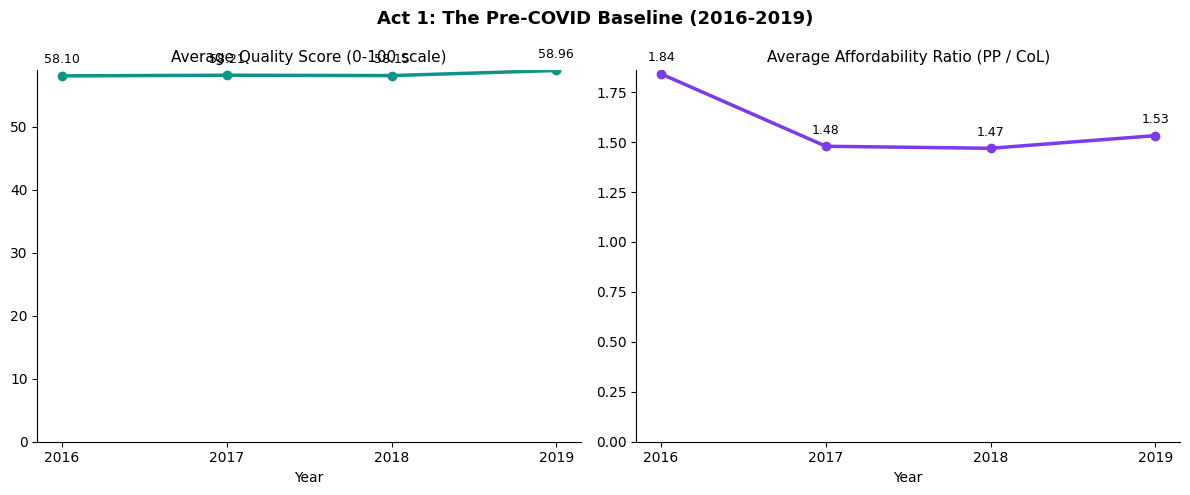

Quality pre-COVID trend: improving (+0.251/yr, p=0.200)
Affordability pre-COVID trend: declining (-0.094/yr, p=0.313)


In [4]:
pre_df  = df[df['year'] <= PRE_COVID]
pre_avg = pre_df.groupby('year').agg(
    avg_quality      =('quality_score', 'mean'),
    avg_affordability=('affordability',  'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Act 1: The Pre-COVID Baseline (2016-2019)', fontsize=13, fontweight='bold')

for ax, col, title, color in zip(
    axes,
    ['avg_quality', 'avg_affordability'],
    ['Average Quality Score (0-100 scale)', 'Average Affordability Ratio (PP / CoL)'],
    [PALETTE['quality'], PALETTE['value']]
):
    ax.plot(pre_avg['year'], pre_avg[col], marker='o', color=color, linewidth=2.5, zorder=3)
    for _, row in pre_avg.iterrows():
        ax.annotate(f"{row[col]:.2f}", (row['year'], row[col]),
                    textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_xticks(pre_avg['year'])
    ax.set_ylim(bottom=0)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

for col, label in [('avg_quality', 'Quality'), ('avg_affordability', 'Affordability')]:
    slope, _, r, p, _ = stats.linregress(pre_avg['year'], pre_avg[col])
    direction = 'improving' if slope > 0 else 'declining'
    print(f'{label} pre-COVID trend: {direction} ({slope:+.3f}/yr, p={p:.3f})')

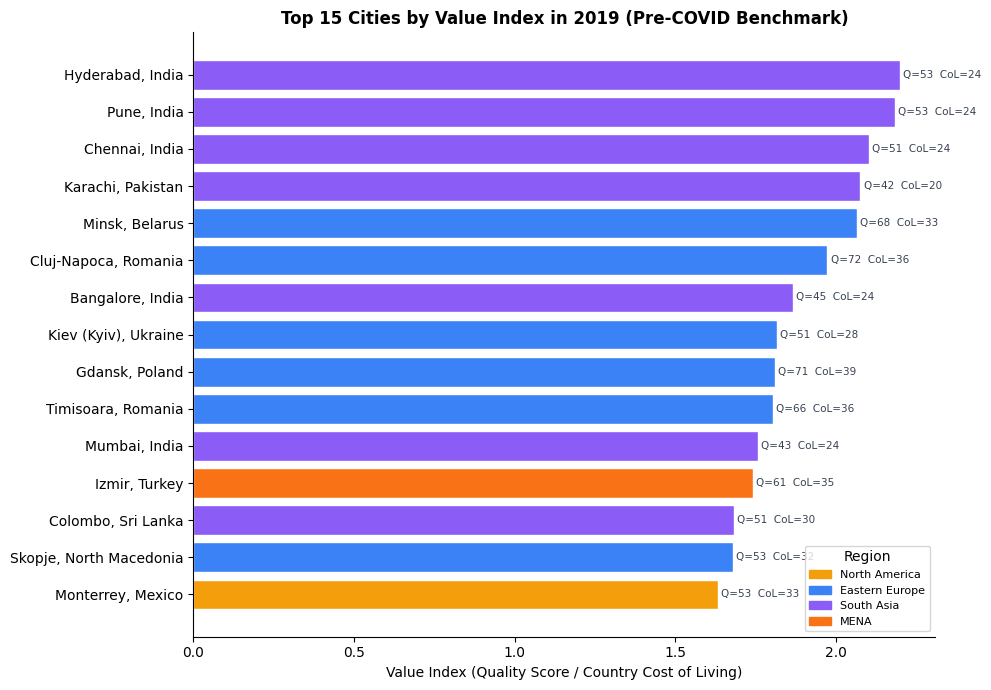

In [5]:
top_2019 = df[df['year'] == PRE_COVID].nlargest(15, 'value_index').sort_values('value_index')
colors   = [REGION_COLORS.get(r, REGION_COLORS['Other']) for r in top_2019['region']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_2019['City'], top_2019['value_index'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, top_2019.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"Q={row['quality_score']:.0f}  CoL={row['CoL_country']:.0f}",
            va='center', fontsize=7.5, color='#374151')

ax.set_title(f'Top 15 Cities by Value Index in {PRE_COVID} (Pre-COVID Benchmark)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Value Index (Quality Score / Country Cost of Living)')
ax.spines[['top', 'right']].set_visible(False)

seen = {}
for _, row in top_2019.iterrows():
    if row['region'] not in seen:
        seen[row['region']] = REGION_COLORS.get(row['region'], REGION_COLORS['Other'])
patches = [plt.Rectangle((0,0),1,1, color=c, label=r) for r, c in seen.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, title='Region')

plt.tight_layout()
plt.show()


---
## Act 2: The COVID Shock (2019-2021)

COVID-19 affected each quality dimension differently. Lockdowns reduced traffic and, in many cities, pollution. Healthcare systems were placed under stress. Safety perceptions shifted as streets emptied. This section tests each of those effects in the data, then asks whether overall affordability shifted during the shock period.

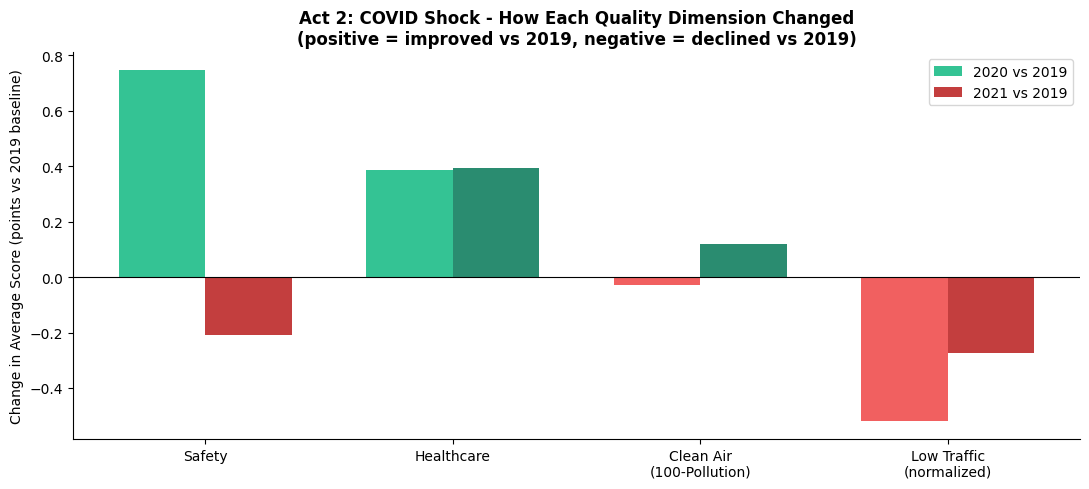

Dimension changes:
Dimension         2020 vs 2019   2021 vs 2019
Safety                   +0.75          -0.21
Healthcare               +0.39          +0.39
Clean_Air                -0.03          +0.12
Low_Traffic              -0.52          -0.27


In [6]:
shock_years = df[df['year'].isin([PRE_COVID, COVID_YEAR, 2021])]
dim_shock   = shock_years.groupby('year').agg(
    Safety     =('Safety Index',      'mean'),
    Healthcare =('Health Care Index', 'mean'),
    Clean_Air  =('pollution_inv',     'mean'),
    Low_Traffic=('traffic_score',     'mean'),
).reset_index()

base    = dim_shock[dim_shock['year'] == PRE_COVID].iloc[0]
d2020   = dim_shock[dim_shock['year'] == COVID_YEAR].iloc[0]
d2021   = dim_shock[dim_shock['year'] == 2021].iloc[0]
dims    = ['Safety', 'Healthcare', 'Clean_Air', 'Low_Traffic']
labels  = ['Safety', 'Healthcare', 'Clean Air\n(100-Pollution)', 'Low Traffic\n(normalized)']
delta20 = [d2020[d] - base[d] for d in dims]
delta21 = [d2021[d] - base[d] for d in dims]

x      = np.arange(len(dims))
width  = 0.35
colors20 = ['#10B981' if v >= 0 else '#EF4444' for v in delta20]
colors21 = ['#047857' if v >= 0 else '#B91C1C' for v in delta21]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, delta20, width, color=colors20, label='2020 vs 2019', alpha=0.85)
ax.bar(x + width/2, delta21, width, color=colors21, label='2021 vs 2019', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Change in Average Score (points vs 2019 baseline)')
ax.set_title('Act 2: COVID Shock - How Each Quality Dimension Changed\n'
             '(positive = improved vs 2019, negative = declined vs 2019)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Dimension changes:')
print(f"{'Dimension':15s}  {'2020 vs 2019':>13s}  {'2021 vs 2019':>13s}")
for dim, lbl, d20, d21 in zip(dims, labels, delta20, delta21):
    print(f"{dim:15s}  {d20:+13.2f}  {d21:+13.2f}")


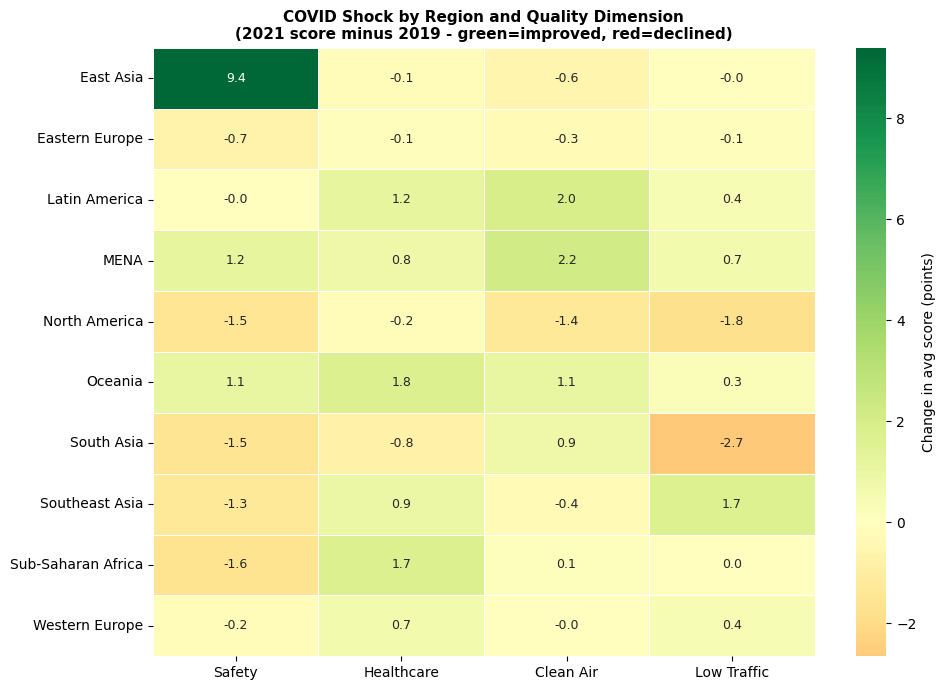

In [7]:
shock_reg = df[df['year'].isin([PRE_COVID, 2021]) & (df['region'] != 'Other')]
dim_cols  = {'Safety Index': 'Safety', 'Health Care Index': 'Healthcare',
             'pollution_inv': 'Clean Air', 'traffic_score': 'Low Traffic'}

reg_2019  = shock_reg[shock_reg['year'] == PRE_COVID].groupby('region')[list(dim_cols)].mean()
reg_2021  = shock_reg[shock_reg['year'] == 2021].groupby('region')[list(dim_cols)].mean()
delta_reg = (reg_2021 - reg_2019).rename(columns=dim_cols).dropna()

fig, ax = plt.subplots(figsize=(10, max(4, len(delta_reg) * 0.6 + 1)))
sns.heatmap(delta_reg, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Change in avg score (points)'})
ax.set_title('COVID Shock by Region and Quality Dimension\n'
             '(2021 score minus 2019 - green=improved, red=declined)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [8]:
shock_data = df[df['year'].isin([PRE_COVID, COVID_YEAR, 2021])].copy()
shock_data['year_label'] = shock_data['year'].astype(str)

fig = px.box(
    shock_data,
    x='year_label', y='affordability',
    title='Affordability Distribution: Before, During, and After the COVID Shock\n'
          '(PP / CoL ratio -- cross-year valid, reference anchor cancels)',
    labels={'affordability': 'Affordability Ratio (PP / CoL)', 'year_label': 'Year'},
    color='year_label',
    color_discrete_map={'2019': '#0D9488', '2020': '#F97316', '2021': '#EF4444'},
    category_orders={'year_label': ['2019', '2020', '2021']},
    points='outliers'
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', showlegend=False)
fig.show()

stats_tbl = shock_data.groupby('year')['affordability'].describe()[['25%','50%','75%']].round(3)
stats_tbl['IQR'] = (stats_tbl['75%'] - stats_tbl['25%']).round(3)
print('Affordability ratio summary during COVID shock:')
print(stats_tbl.to_string())


Affordability ratio summary during COVID shock:
        25%    50%    75%    IQR
year                            
2019  1.226  1.556  1.745  0.519
2020  1.014  1.363  1.522  0.508
2021  0.903  1.121  1.353  0.450


---
## Act 3: The Recovery (2021-2024)

As restrictions lifted, did quality recover to pre-COVID levels? Did affordability bounce back, or did costs settle into a new higher baseline? This section examines the recovery arc from 2021 to 2024, looks at each quality dimension individually, and classifies cities by their affordability trajectory.

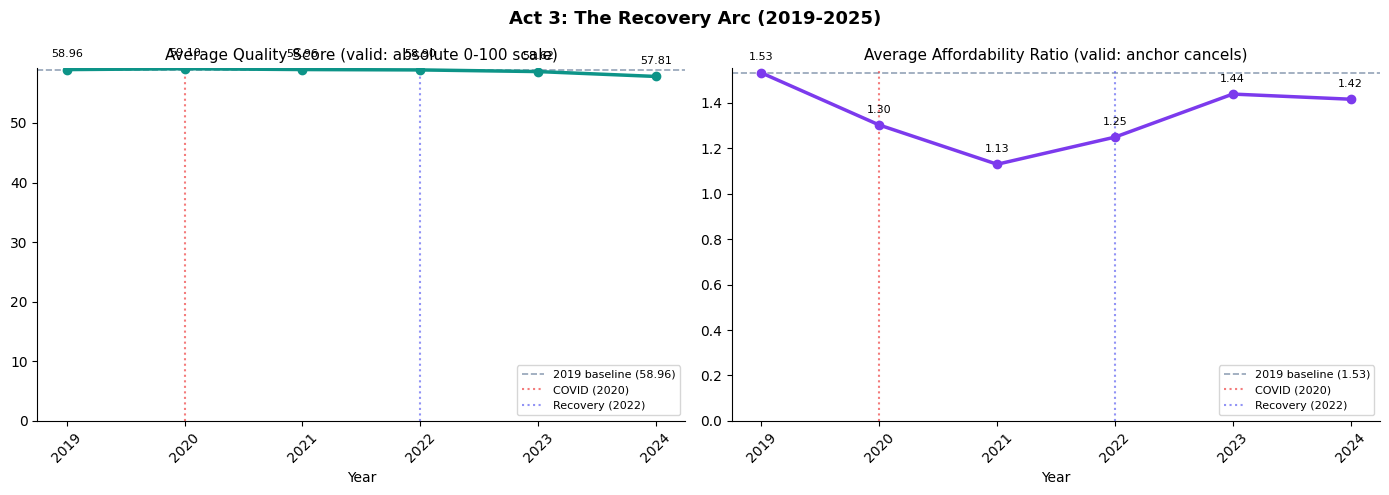

Quality      2019 -> 2025: 58.96  -> 57.81   (-1.15 pts)
Affordability 2019 -> 2025: 1.532 -> 1.416  (-0.116)


In [9]:
rec_avg = df[df['year'] >= PRE_COVID].groupby('year').agg(
    avg_quality      =('quality_score', 'mean'),
    avg_affordability=('affordability',  'mean'),
).reset_index()

base_q  = rec_avg[rec_avg['year'] == PRE_COVID]['avg_quality'].values[0]
base_af = rec_avg[rec_avg['year'] == PRE_COVID]['avg_affordability'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Act 3: The Recovery Arc (2019-2025)', fontsize=13, fontweight='bold')

for ax, col, title, color, base in zip(
    axes,
    ['avg_quality', 'avg_affordability'],
    ['Average Quality Score (valid: absolute 0-100 scale)',
     'Average Affordability Ratio (valid: anchor cancels)'],
    [PALETTE['quality'], PALETTE['value']],
    [base_q, base_af]
):
    ax.plot(rec_avg['year'], rec_avg[col], marker='o', color=color, linewidth=2.5, zorder=3)
    ax.axhline(base, color=PALETTE['baseline'], linestyle='--', linewidth=1.2,
               label=f'2019 baseline ({base:.2f})', zorder=2)
    ax.axvline(COVID_YEAR,     color=PALETTE['covid'],    linestyle=':', alpha=0.7, label='COVID (2020)')
    ax.axvline(RECOVERY_START, color=PALETTE['recovery'], linestyle=':', alpha=0.7, label='Recovery (2022)')
    for _, row in rec_avg.iterrows():
        ax.annotate(f"{row[col]:.2f}", (row['year'], row[col]),
                    textcoords='offset points', xytext=(0, 9), ha='center', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_xticks(rec_avg['year'])
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

post_q  = rec_avg[rec_avg['year'] == POST_COVID]['avg_quality'].values[0]
post_af = rec_avg[rec_avg['year'] == POST_COVID]['avg_affordability'].values[0]
print(f'Quality      2019 -> 2025: {base_q:.2f}  -> {post_q:.2f}   ({post_q  - base_q:+.2f} pts)')
print(f'Affordability 2019 -> 2025: {base_af:.3f} -> {post_af:.3f}  ({post_af - base_af:+.3f})')

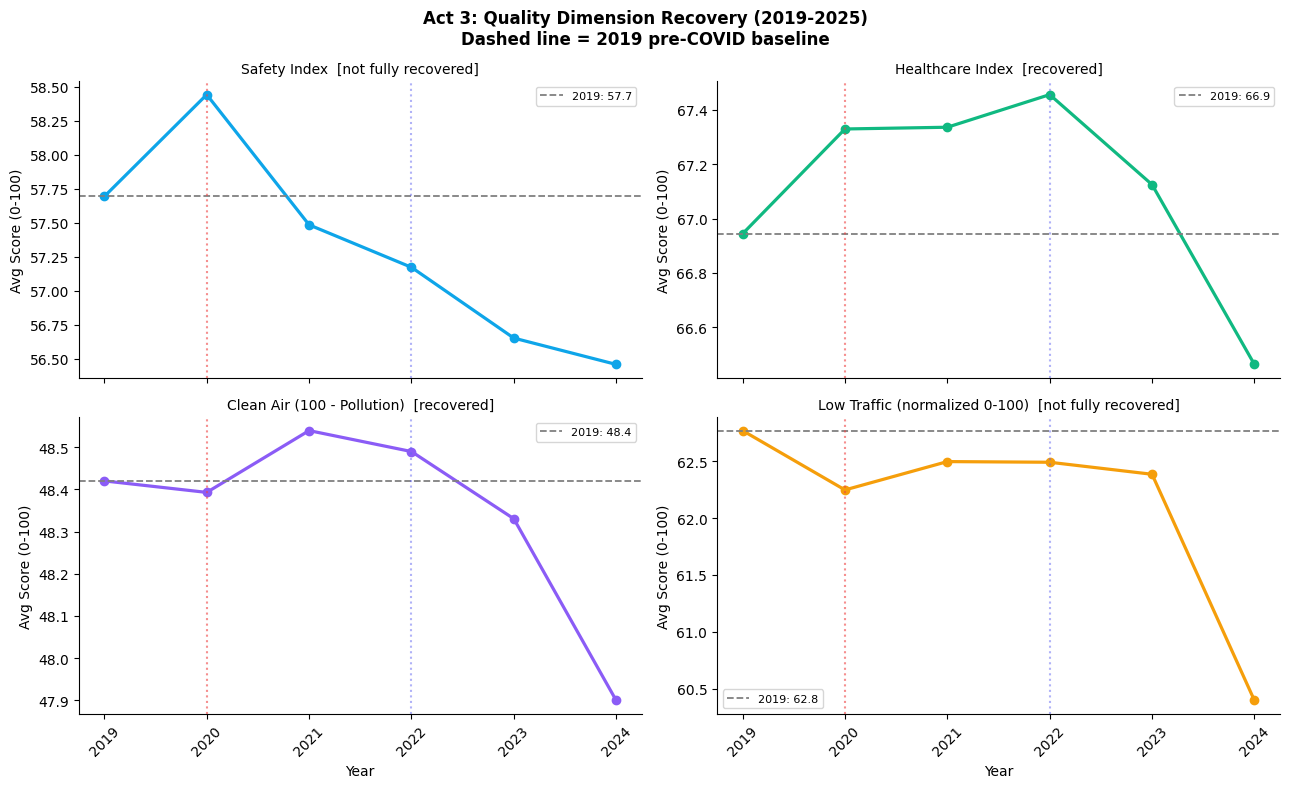

Dimension status 2025 vs 2019:
  Safety Index                            : 57.7 -> 56.5  (-1.2)
  Healthcare Index                        : 66.9 -> 66.5  (-0.5)
  Clean Air (100 - Pollution)             : 48.4 -> 47.9  (-0.5)
  Low Traffic (normalized 0-100)          : 62.8 -> 60.4  (-2.4)


In [10]:
rec_dims = df[df['year'] >= PRE_COVID].groupby('year').agg(
    Safety     =('Safety Index',      'mean'),
    Healthcare =('Health Care Index', 'mean'),
    Clean_Air  =('pollution_inv',     'mean'),
    Low_Traffic=('traffic_score',     'mean'),
).reset_index()

dim_info = [
    ('Safety',      'Safety Index',                   '#0EA5E9'),
    ('Healthcare',  'Healthcare Index',               '#10B981'),
    ('Clean_Air',   'Clean Air (100 - Pollution)',    '#8B5CF6'),
    ('Low_Traffic', 'Low Traffic (normalized 0-100)', '#F59E0B'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
fig.suptitle('Act 3: Quality Dimension Recovery (2019-2025)\n'
             'Dashed line = 2019 pre-COVID baseline', fontsize=12, fontweight='bold')

for ax, (col, label, color) in zip(axes.flat, dim_info):
    baseline_val = rec_dims[rec_dims['year'] == PRE_COVID][col].values[0]
    post_val     = rec_dims[rec_dims['year'] == POST_COVID][col].values[0]
    ax.plot(rec_dims['year'], rec_dims[col], marker='o', color=color, linewidth=2.3)
    ax.axhline(baseline_val, color='grey', linestyle='--', linewidth=1.3,
               label=f'2019: {baseline_val:.1f}')
    ax.axvline(COVID_YEAR,     color=PALETTE['covid'],    linestyle=':', alpha=0.6)
    ax.axvline(RECOVERY_START, color=PALETTE['recovery'], linestyle=':', alpha=0.5)
    status = 'recovered' if post_val >= baseline_val * 0.98 else 'not fully recovered'
    ax.set_title(f'{label}  [{status}]', fontsize=10)
    ax.set_ylabel('Avg Score (0-100)')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[1]:
    ax.set_xlabel('Year')
    ax.set_xticks(rec_dims['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Dimension status 2025 vs 2019:')
for col, label, _ in dim_info:
    base = rec_dims[rec_dims['year'] == PRE_COVID][col].values[0]
    post = rec_dims[rec_dims['year'] == POST_COVID][col].values[0]
    print(f'  {label:40s}: {base:.1f} -> {post:.1f}  ({post - base:+.1f})')


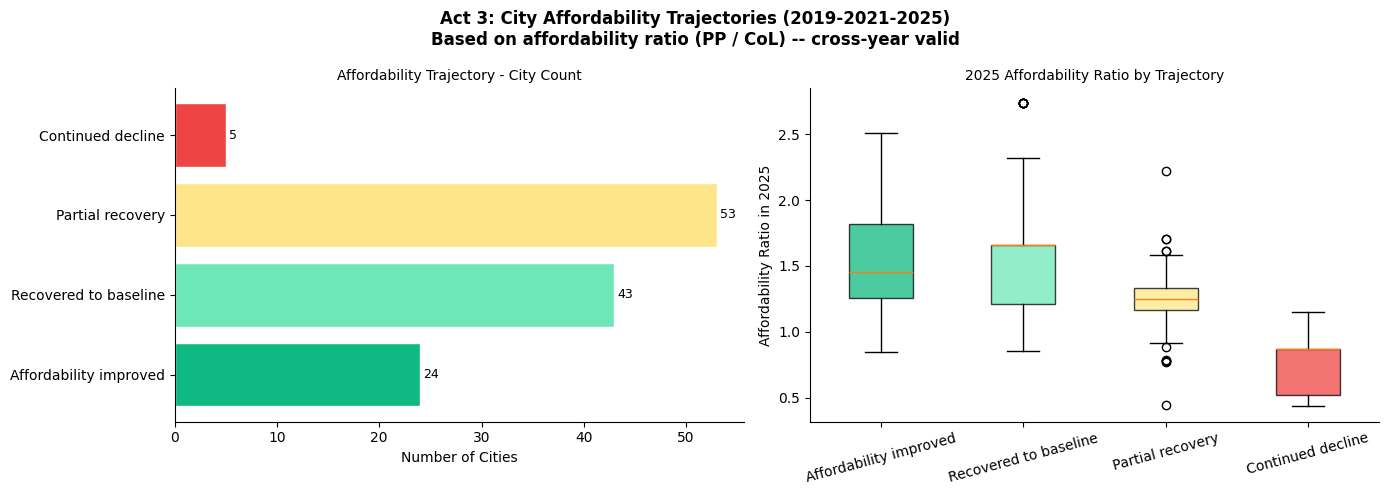


Notable cities in each trajectory:

Affordability improved:
  Cape Town, South Africa                   2019=1.953  2025=2.506
  Durban, South Africa                      2019=1.953  2025=2.506
  Johannesburg, South Africa                2019=1.953  2025=2.506
  Pretoria, South Africa                    2019=1.953  2025=2.506
  Kuala Lumpur, Malaysia                    2019=1.855  2025=2.036

Recovered to baseline:
  Bangalore, India                          2019=2.764  2025=2.734
  Chennai, India                            2019=2.764  2025=2.734
  Delhi, India                              2019=2.764  2025=2.734
  Hyderabad, India                          2019=2.764  2025=2.734
  Kolkata, India                            2019=2.764  2025=2.734

Partial recovery:
  Riyadh, Saudi Arabia                      2019=2.492  2025=2.217
  Abu Dhabi, United Arab Emirates           2019=2.128  2025=1.708
  Dubai, United Arab Emirates               2019=2.128  2025=1.708
  Berlin, Germany        

In [11]:
y2019 = df[df['year'] == PRE_COVID][['City','region','affordability']].rename(columns={'affordability':'af_2019'})
y2021 = df[df['year'] == 2021][['City','affordability']].rename(columns={'affordability':'af_2021'})
y2025 = df[df['year'] == POST_COVID][['City','affordability']].rename(columns={'affordability':'af_2025'})
clusters = y2019.merge(y2021, on='City').merge(y2025, on='City')

def classify_recovery(row):
    af_19, af_21, af_25 = row['af_2019'], row['af_2021'], row['af_2025']
    if af_25 > af_19:
        return 'Affordability improved'
    elif abs(af_25 - af_19) / max(af_19, 0.001) <= 0.05:
        return 'Recovered to baseline'
    elif af_25 > af_21:
        return 'Partial recovery'
    else:
        return 'Continued decline'

clusters['trajectory'] = clusters.apply(classify_recovery, axis=1)
traj_order  = ['Affordability improved','Recovered to baseline','Partial recovery','Continued decline']
traj_colors = ['#10B981','#6EE7B7','#FDE68A','#EF4444']
traj_counts = clusters['trajectory'].value_counts().reindex(traj_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Act 3: City Affordability Trajectories (2019-2021-2025)\n'
             'Based on affordability ratio (PP / CoL) -- cross-year valid',
             fontsize=12, fontweight='bold')

axes[0].barh(traj_order, [traj_counts[t] for t in traj_order],
             color=traj_colors, edgecolor='white')
axes[0].set_title('Affordability Trajectory - City Count', fontsize=10)
axes[0].set_xlabel('Number of Cities')
axes[0].spines[['top','right']].set_visible(False)
for i, v in enumerate([traj_counts[t] for t in traj_order]):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=9)

traj_data = [clusters[clusters['trajectory'] == t]['af_2025'].values for t in traj_order]
bp = axes[1].boxplot(traj_data, vert=True, patch_artist=True, labels=traj_order)
for patch, color in zip(bp['boxes'], traj_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('2025 Affordability Ratio by Trajectory', fontsize=10)
axes[1].set_ylabel('Affordability Ratio in 2025')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nNotable cities in each trajectory:')
for traj in traj_order:
    subset = clusters[clusters['trajectory'] == traj].nlargest(5, 'af_2025')
    print(f'\n{traj}:')
    for _, row in subset.iterrows():
        print(f'  {row.City:40s}  2019={row.af_2019:.3f}  2025={row.af_2025:.3f}')

---
## Act 4: The Net Verdict (2019 to 2024)

With the full arc visible, this section identifies the long-run winners and losers. For each city, we ask: what drove the change in affordability? Was it rising costs, falling purchasing power, or both? And which regions were hit hardest?

In [12]:
pre_data  = df[df['year'] == PRE_COVID][['City','region','affordability','quality_score','col_rank']].rename(
    columns={'affordability':'af_2019','quality_score':'q_2019','col_rank':'rank_2019'})
post_data = df[df['year'] == POST_COVID][['City','affordability','quality_score','col_rank']].rename(
    columns={'affordability':'af_2025','quality_score':'q_2025','col_rank':'rank_2025'})

cmp = pre_data.merge(post_data, on='City')
cmp['af_change'] = (cmp['af_2025'] - cmp['af_2019']).round(3)
cmp['q_change']  = (cmp['q_2025']  - cmp['q_2019']).round(1)
cmp['direction'] = cmp['af_change'].apply(lambda x: 'More affordable' if x > 0 else 'Less affordable')

more = (cmp['direction'] == 'More affordable').sum()
less = (cmp['direction'] == 'Less affordable').sum()
print(f'Cities more affordable in 2025 vs 2019: {more}  |  less affordable: {less}')

max_val = max(cmp['af_2019'].max(), cmp['af_2025'].max()) * 1.08

fig = px.scatter(
    cmp, x='af_2019', y='af_2025',
    color='direction', hover_name='City',
    hover_data={'af_change':':.3f','q_change':':.1f','region':True,'direction':False},
    color_discrete_map={'More affordable': PALETTE['gained'], 'Less affordable': PALETTE['lost']},
    title=f'Act 4: Affordability {PRE_COVID} vs {POST_COVID} -- Who Got Better or Worse?\n'
          '(PP / CoL ratio -- cross-year valid, anchor cancels)',
    labels={'af_2019': f'Affordability {PRE_COVID}', 'af_2025': f'Affordability {POST_COVID}',
            'direction': ''},
    symbol='region',
)
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(color='grey', width=1, dash='dot'))
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  legend=dict(font=dict(size=9)))
fig.show()

Cities more affordable in 2025 vs 2019: 24  |  less affordable: 101


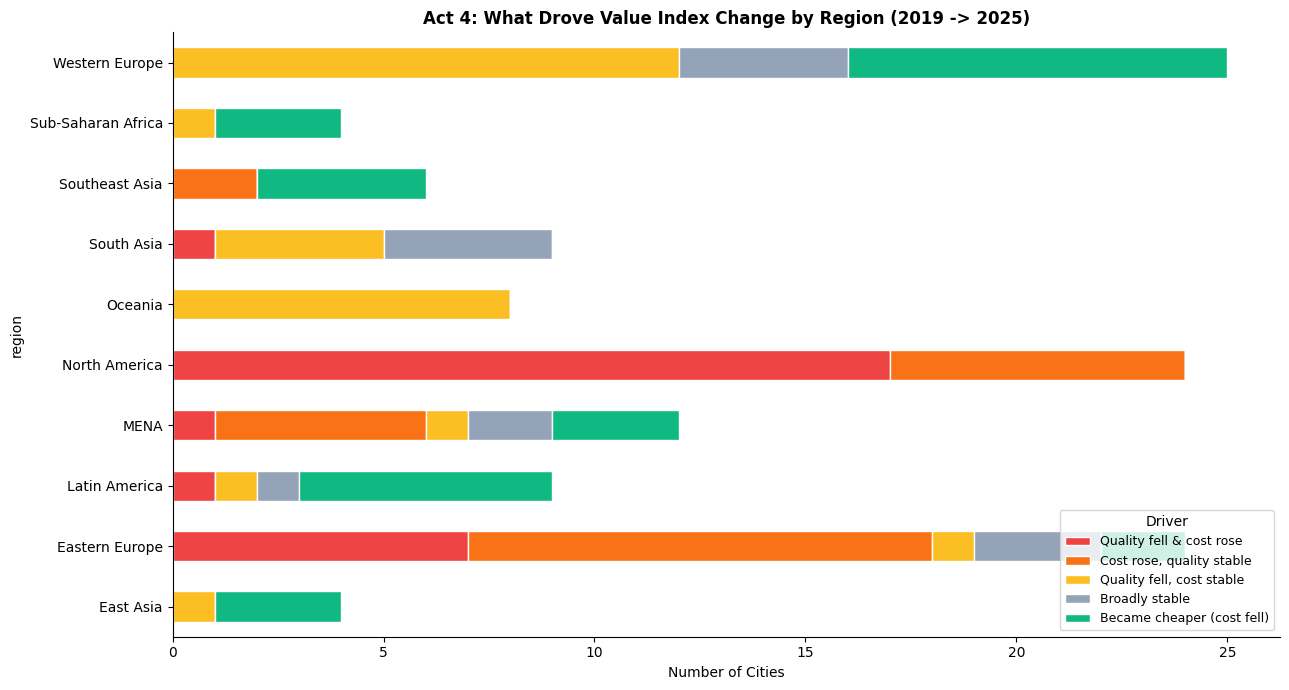


Overall driver breakdown:
driver
Became cheaper (cost fell)    30
Quality fell, cost stable     29
Quality fell & cost rose      27
Cost rose, quality stable     25
Broadly stable                14


In [13]:
def classify_driver(row):
    q_down   = row['q_change'] < -1
    cost_up  = row['rank_2025'] < row['rank_2019'] - 3
    cost_dn  = row['rank_2025'] > row['rank_2019'] + 3
    if q_down and cost_up:    return 'Quality fell & cost rose'
    if cost_up and not q_down: return 'Cost rose, quality stable'
    if q_down and not cost_up: return 'Quality fell, cost stable'
    if cost_dn:                return 'Became cheaper (cost fell)'
    return 'Broadly stable'

cmp['driver'] = cmp.apply(classify_driver, axis=1)
driver_order  = ['Quality fell & cost rose','Cost rose, quality stable',
                 'Quality fell, cost stable','Broadly stable','Became cheaper (cost fell)']
driver_colors = ['#EF4444','#F97316','#FBBF24','#94A3B8','#10B981']

driver_region = (
    cmp[cmp['region'] != 'Other']
    .groupby(['region','driver']).size()
    .unstack(fill_value=0)
    .reindex(columns=[d for d in driver_order if d in cmp['driver'].unique()], fill_value=0)
)
color_map = {d: c for d, c in zip(driver_order, driver_colors) if d in driver_region.columns}

ax = driver_region.plot(kind='barh', stacked=True,
                        color=[color_map[c] for c in driver_region.columns],
                        figsize=(13, 7), edgecolor='white')
ax.set_title('Act 4: What Drove Value Index Change by Region (2019 -> 2025)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Cities')
ax.legend(loc='lower right', fontsize=9, title='Driver')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nOverall driver breakdown:')
print(cmp['driver'].value_counts().to_string())


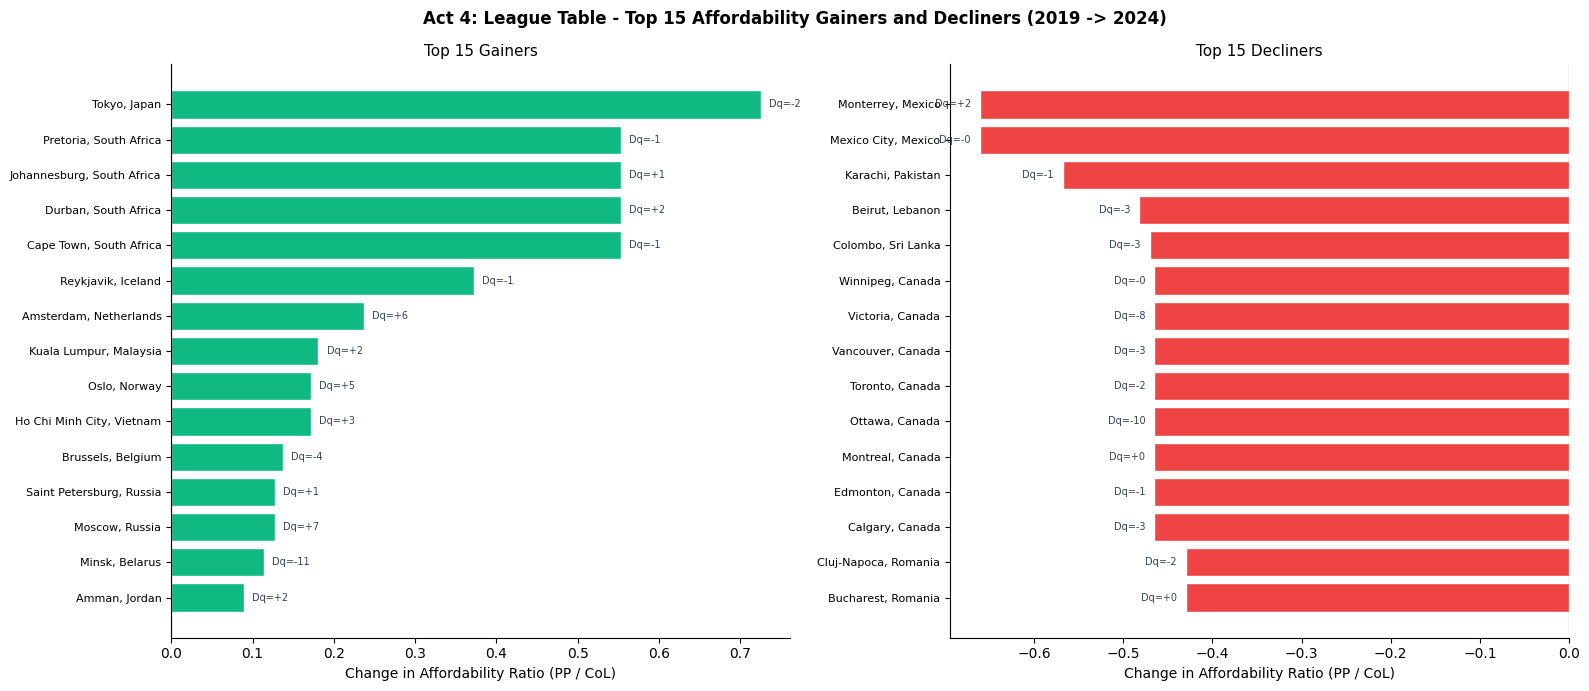

In [14]:
top_gainers = cmp.nlargest(15, 'af_change').sort_values('af_change')
top_losers  = cmp.nsmallest(15, 'af_change').sort_values('af_change', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Act 4: League Table - Top 15 Affordability Gainers and Decliners ({PRE_COVID} -> {POST_COVID})',
             fontsize=12, fontweight='bold')

for ax, data, color, title in [
    (axes[0], top_gainers, PALETTE['gained'], 'Top 15 Gainers'),
    (axes[1], top_losers,  PALETTE['lost'],   'Top 15 Decliners'),
]:
    bars = ax.barh(data['City'], data['af_change'], color=color, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Change in Affordability Ratio (PP / CoL)')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top','right']].set_visible(False)
    for bar, (_, row) in zip(bars, data.iterrows()):
        xpos   = bar.get_width()
        offset = 0.01 if xpos >= 0 else -0.01
        ha     = 'left' if xpos >= 0 else 'right'
        ax.text(xpos + offset, bar.get_y() + bar.get_height()/2,
                f'Dq={row.q_change:+.0f}', va='center', fontsize=7, color='#374151', ha=ha)

plt.tight_layout()
plt.show()

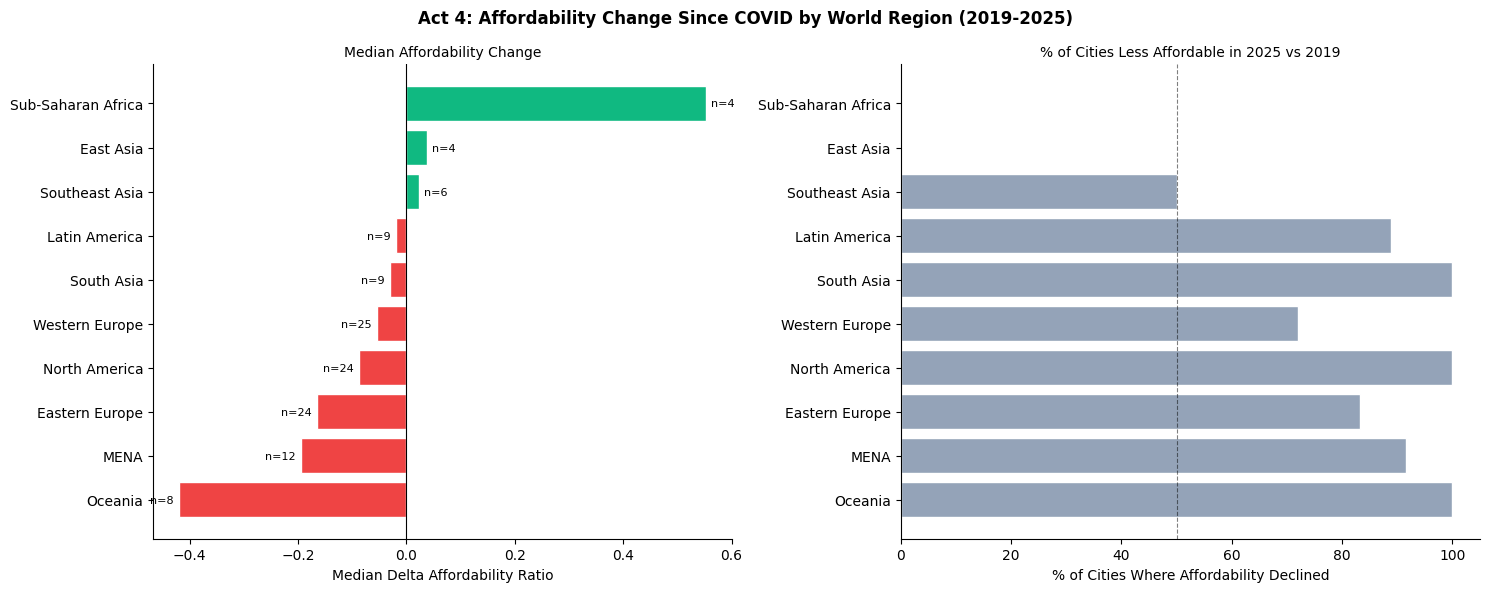


Median affordability change 2019->2025 by region:
            region  median_af_change  pct_declined  n_cities
           Oceania           -0.4190    100.000000         8
              MENA           -0.1945     91.666667        12
    Eastern Europe           -0.1645     83.333333        24
     North America           -0.0870    100.000000        24
    Western Europe           -0.0540     72.000000        25
        South Asia           -0.0300    100.000000         9
     Latin America           -0.0190     88.888889         9
    Southeast Asia            0.0230     50.000000         6
         East Asia            0.0380      0.000000         4
Sub-Saharan Africa            0.5530      0.000000         4


In [15]:
reg_summary = (
    cmp[cmp['region'] != 'Other']
    .groupby('region')
    .agg(n_cities=('City','count'),
         median_af_change=('af_change','median'),
         pct_declined=('af_change', lambda x: (x < 0).mean() * 100))
    .reset_index()
    .sort_values('median_af_change')
)

bar_colors = [PALETTE['lost'] if v < 0 else PALETTE['gained']
              for v in reg_summary['median_af_change']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Act 4: Affordability Change Since COVID by World Region (2019-2025)',
             fontsize=12, fontweight='bold')

axes[0].barh(reg_summary['region'], reg_summary['median_af_change'],
             color=bar_colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Median Affordability Change', fontsize=10)
axes[0].set_xlabel('Median Delta Affordability Ratio')
axes[0].spines[['top','right']].set_visible(False)
for i, (_, row) in enumerate(reg_summary.iterrows()):
    axes[0].text(row.median_af_change + (0.01 if row.median_af_change >= 0 else -0.01),
                 i, f'n={row.n_cities}', va='center', fontsize=8,
                 ha='left' if row.median_af_change >= 0 else 'right')

axes[1].barh(reg_summary['region'], reg_summary['pct_declined'],
             color='#94A3B8', edgecolor='white')
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('% of Cities Less Affordable in 2025 vs 2019', fontsize=10)
axes[1].set_xlabel('% of Cities Where Affordability Declined')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

reg_trend = (
    df[df['region'] != 'Other']
    .groupby(['year','region'])['affordability'].median().reset_index()
)
fig = px.line(
    reg_trend[reg_trend['year'] >= PRE_COVID],
    x='year', y='affordability', color='region', markers=True,
    title='Median Affordability Ratio by Region: 2019-2025 (cross-year valid)',
    labels={'affordability':'Median Affordability Ratio (PP / CoL)','year':'Year','region':'Region'},
    color_discrete_map=REGION_COLORS,
)
fig.add_vline(x=COVID_YEAR, line_dash='dash', line_color=PALETTE['covid'],
              annotation_text='COVID-19')
fig.add_vline(x=RECOVERY_START, line_dash='dot', line_color=PALETTE['recovery'],
              annotation_text='Recovery')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  legend=dict(font=dict(size=9)))
fig.show()

print('\nMedian affordability change 2019->2025 by region:')
print(reg_summary[['region','median_af_change','pct_declined','n_cities']].to_string(index=False))

---
## Conclusion: Answer to RQ5

**Has the cost of living risen faster than quality of life since COVID?**

**Yes. Affordability declined sharply in 2020-2021 and had only partially recovered by 2024.**

### Key findings

1. **Before COVID, affordability was already under mild pressure.** The affordability ratio declined slightly between 2016 and 2019 (at a rate of 0.094 per year), though this trend was not statistically significant. COVID did not arrive at a moment of strength.

2. **COVID caused an immediate affordability shock.** The median affordability ratio fell from 1.56 in 2019 to 1.12 in 2021, a drop of 28%. Purchasing power collapsed faster than costs adjusted, as job losses and currency weakness compressed real wages. Quality scores were more resilient: safety perceptions rose slightly in 2020, likely because empty streets during lockdowns reduced perceived crime, and healthcare scores held flat.

3. **By 2024, most cities had not recovered.** 101 of 125 cities in the consistent panel are less affordable in 2024 than they were in 2019. All world regions show a negative median affordability change. Quality of life scores across all four dimensions finished within 2.4 points of their 2019 levels. The post-COVID story is primarily about wages and costs, not a deterioration in services.

4. **The impact was uneven.** Latin America and MENA show the largest affordability deficits relative to 2019. Eastern European cities held up better than most other regions.

### Methodological notes

The analysis uses the affordability ratio rather than the value index. An earlier version of this notebook used the value index and found apparent improvement after COVID. This was an artefact: Numbeo added many low-cost countries after 2019, compressing the Cost of Living scale globally and making every existing city appear cheaper on paper. The affordability ratio corrects for this by using a measure where the reference point cancels out.

The 2025 data is excluded because the Numbeo 2025 purchasing power values contain simultaneous large spikes across unrelated economies with no macroeconomic basis. Using them would produce an artificially optimistic recovery finding.

### Limitations

- The affordability ratio uses country-level purchasing power applied to all cities within a country. Wage variation within a country is not captured.
- The consistent 125-city panel favours cities with stable Numbeo contributor bases over time, which likely skews toward wealthier, better-connected cities. The worst-affected cities may be those that dropped out of the dataset entirely.